In [1]:
#################################################################################
# Main script to run UP-MAVT analysis
#
# Simone Pagliuca, 2025-2026
#
# Description:
# TBC....
#################################################################################

#################################################################################
# Import third party libraries
import numpy as np
# import matplotlib
# matplotlib.use('TkAgg')  # Set backend before importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
#################################################################################

#################################################################################
# Import internal modules
from pile_bwt import bwt, constraints_func
from up_mavt import startup, mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import obtain_weight_space_description
#################################################################################

#################################################################################
# USER INPUTS
# Weight elicitation files (one per elicitation / run)
file_path_weight_elicitations = ["wbt_results_1.csv"]

# Value function files (one per elicitation / run)
file_path_value_functions = ["value_functions_1.csv"]

# Criteria definitions file
file_path_criteria = "criteria.csv"

# Montecarlo Parameters
n_runs = 10000
PLOTS = True  # Toggle plots
UPDATE_EVERY = 10  # Update plots every N runs
#################################################################################


#################################################################################
# Startup: Load all data
dict_data_list, crit_index, vf_list, alternatives = startup(file_path_criteria, file_path_weight_elicitations, file_path_value_functions)
n_alternatives = len(alternatives)
print(f"Loaded {len(dict_data_list)} elicitation(s) with {n_alternatives} alternatives.")
#################################################################################


Number of criteria identified: 15
Loading criteria definitions and attaching value functions...
Starting loop over weight elicitation files...
Processing file 1/1: wbt_results_1.csv
Loaded 1 elicitation(s) with 6 alternatives.


In [2]:

#################################################################################
# PILE-BWT Method
# 
# Work in progress while we try to fix issues with constraints and solver
# For now it runs the BWT optimization and then tries to sample more values from the space
print("Running BWT for each elicitation...")
bwt_results = []

for i, dict_data in enumerate(dict_data_list):
    print(f"Running BWT for elicitation {i+1}...")  # Debugging: Print elicitation index
    bwt_result = bwt(dict_data)
    bwt_results.append(bwt_result)
    
print(bwt_result["solver_result"])



Running BWT for each elicitation...
Running BWT for elicitation 1...
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=7.170429431013758e-05
COBYLA produced near-feasible solution: accepting result.
 message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.
 success: True
  status: 0
     fun: 5.350032984846991
       x: [ 5.396e-02  1.945e-02 ...  1.069e-01  5.350e+00]
    nfev: 680
   maxcv: 7.170429431013758e-05


In [3]:

print("\033[93mTesting with BWT results...\033[0m")
x_weights = bwt_result["solver_result"]["x"][:-1]
x_temp = np.concatenate([x_weights, [0]])
constraint_value = constraints_func(x_temp, dict_data)
error_b = min(max([abs(cv) for cv in constraint_value]), 10)
for c in constraint_value:
    c_py = float(c)
    print(c_py)  # Debugging: print as native Python float
print(f"\033[91mMaximum constraint violation (error_b): {error_b}\033[0m")  # Debugging
known_max_error = error_b
print("\n")
print(x_weights)


Testing with BWT results...
-1.7885568948430375
-0.5987646312480489
-1.1464256239700257
-1.2110934106024962
-3.5243083234312556
-3.05649137784878
-5.138522628962949
-4.3258198214520105
-5.198342635991388
-5.350095569397489
-5.350104689141301
-0.565659045395405
-5.350095745721221
-0.02607973107964856
-2.2677830081054076
-0.151572316834663
-1.1156349971644943
-3.941193910357204
-0.942481662782948
-1.0453276768168578
-0.0636876625518783
-0.8893113862351394
-0.6804411408006871
-3.105045680596322
-0.3640938836794767
-2.270889346530912
-5.3500752248985695
-5.350073196361979
Maximum constraint violation (error_b): 5.350104689141301


[0.05395801 0.01944853 0.13939782 0.08942755 0.05101891 0.02041521
 0.12233785 0.00552146 0.06456888 0.12049677 0.04848663 0.08946097
 0.04936324 0.01921532 0.1069453 ]


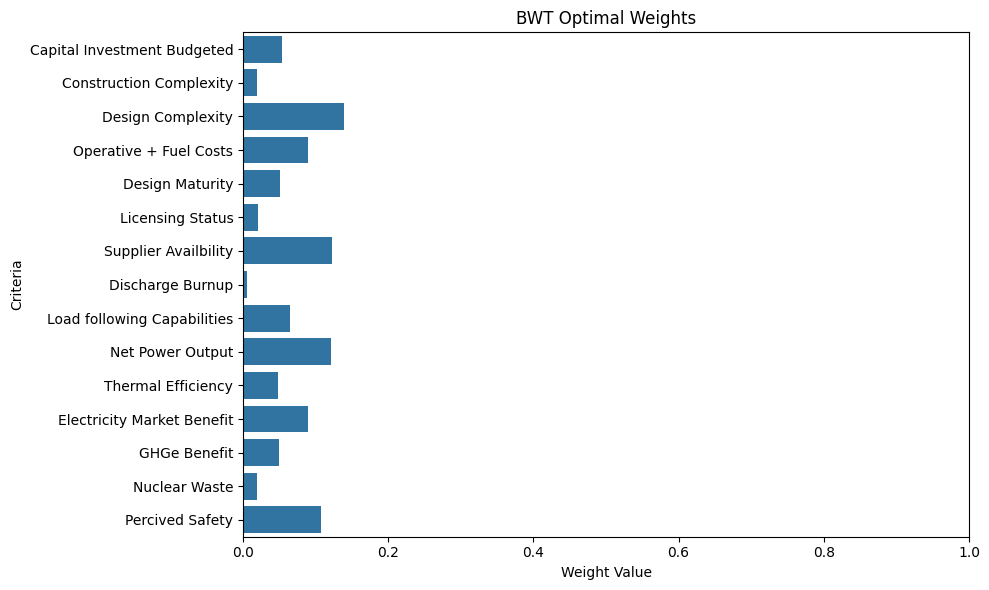

In [4]:
# Plot the BWT weights as horizontal bars
plt.figure(figsize=(10, 6))
sns.barplot(y=list(crit_index.keys()), x=x_weights, orient='h')
plt.title("BWT Optimal Weights")
plt.xlabel("Weight Value")
plt.ylabel("Criteria")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
#################################################################################

In [5]:

from weight_sampling import obtain_weight_space_description
num_criteria = len(x_weights)
used_cells = set()
grid_size = np.int64(1000)
n_dimensions = num_criteria
# print("Number of dimensions for sampling:", n_dimensions)
nx = np.array([grid_size] * n_dimensions, dtype=np.int64)

initial_point = bwt_result["solver_result"]["x"][:num_criteria]
# print("Initial point for sampling:", initial_point)
initial_cell = tuple(np.clip((np.array(initial_point) * grid_size).astype(np.int64), 0, grid_size - 1))
used_cells.add(initial_cell)
valid_points = [np.array(initial_cell, dtype=np.float64) / grid_size]

print("Starting space sampling...")
print(f"Grid size: {grid_size}, Number of dimensions: {n_dimensions}")
print(f"Initial point: {initial_point}, Initial cell: {initial_cell}")


Starting space sampling...
Grid size: 1000, Number of dimensions: 15
Initial point: [0.05395801 0.01944853 0.13939782 0.08942755 0.05101891 0.02041521
 0.12233785 0.00552146 0.06456888 0.12049677 0.04848663 0.08946097
 0.04936324 0.01921532 0.1069453 ], Initial cell: (np.int64(53), np.int64(19), np.int64(139), np.int64(89), np.int64(51), np.int64(20), np.int64(122), np.int64(5), np.int64(64), np.int64(120), np.int64(48), np.int64(89), np.int64(49), np.int64(19), np.int64(106))


In [6]:
print(sum(initial_point))

1.0000624557958797


In [7]:
print(known_max_error)

5.350104689141301


Generating weight samples for elicitation 1...
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=6.839535283464926e-05
COBYLA produced near-feasible solution: accepting result.
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=3.248225960206241e-05
COBYLA produced near-feasible solution: accepting result.
Running optimization...
Trying 'COBYLA' as fallback with explicit bound constraints...
COBYLA failed (message: Did not converge to a solution satisfying the constraints. See `maxcv` for the magnitude of the violation.)
maxcv=6.343626731375451e-05
COBYLA produced near-feasible solution: accepting result.
Running optimization...
Trying 'COBYLA

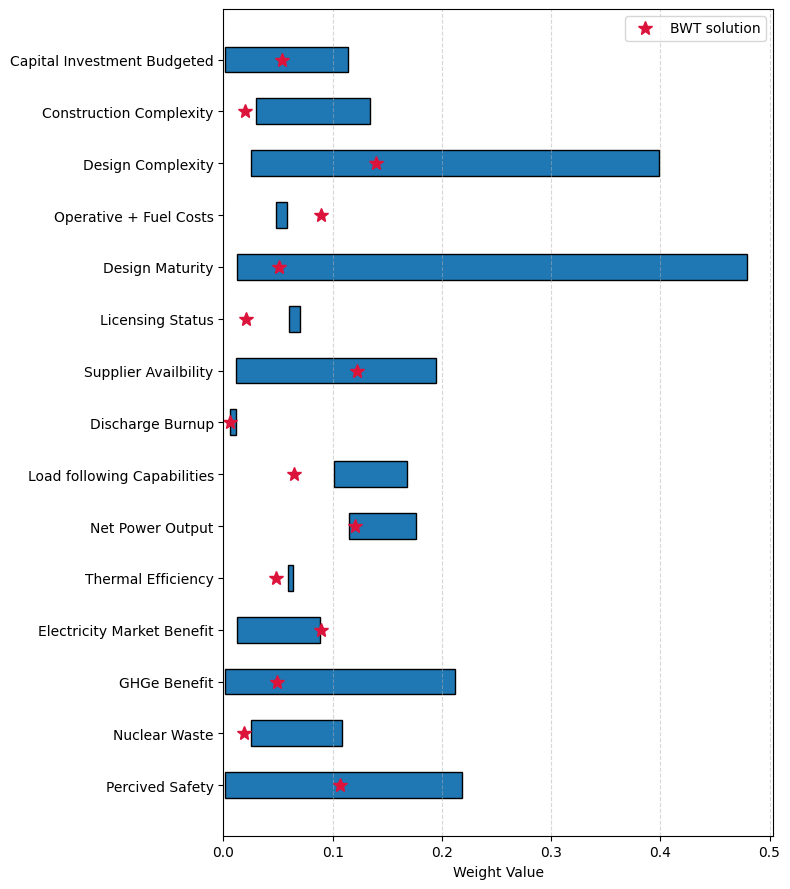

Total weight combinations to sample: 1703495509259190272 (values rounded to 3 decimals)


In [8]:
list_of_weight_space_points = obtain_weight_space_description(bwt_results, dict_data_list, file_path_weight_elicitations, crit_index)

In [9]:
# We then seelct one of the elicitated spaces
weight_space_points = list_of_weight_space_points[0]
print(weight_space_points)

[[0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.02, 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027, 0.028, 0.029, 0.03, 0.031, 0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.04, 0.041, 0.042, 0.043, 0.044, 0.045, 0.046, 0.047, 0.048, 0.049, 0.05, 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058, 0.059, 0.06, 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07, 0.071, 0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079, 0.08, 0.081, 0.082, 0.083, 0.084, 0.085, 0.086, 0.087, 0.088, 0.089, 0.09, 0.091, 0.092, 0.093, 0.094, 0.095, 0.096, 0.097, 0.098, 0.099, 0.1, 0.101, 0.102, 0.103, 0.104, 0.105, 0.106, 0.107, 0.108, 0.109, 0.11, 0.111, 0.112, 0.113, 0.114, 0.115], [0.031, 0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.04, 0.041, 0.042, 0.043, 0.044, 0.045, 0.046, 0.047, 0.048, 0.049, 0.05, 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058, 0.059, 0.

In [24]:
from weight_sampling import weight_sampler
weight_sampler(dict_data, weight_space_points)

Sampled weights: [np.float64(0.066), np.float64(0.044), np.float64(0.052), np.float64(0.056), np.float64(0.056), np.float64(0.068), np.float64(0.103), np.float64(0.011), np.float64(0.131), np.float64(0.128), np.float64(0.063), np.float64(0.03), np.float64(0.074), np.float64(0.08), np.float64(0.039)], sum: 1.001, constraints satisfied: [np.float64(-0.5141560798527318), np.float64(-0.283386849083501), np.float64(-0.5712253856940794), np.float64(-0.6428571428571429), np.float64(-4.154516213720715), np.float64(-4.732026143790849), np.float64(-5.011866235167205), np.float64(-0.15196078431372584), np.float64(-4.988636363528467), np.float64(-8.404306221401487), np.float64(-5.565033875548571), np.float64(-0.07807720773813287), np.float64(-4.602414758622432), np.float64(-4.254629629629631), np.float64(-3.9117346938756947), np.float64(-0.2561314230538376), np.float64(-0.5238346795723844), np.float64(-1.1369314489928521), np.float64(-0.4486189633542734), np.float64(-0.3544331351708401), np.float6

[np.float64(0.066),
 np.float64(0.044),
 np.float64(0.052),
 np.float64(0.056),
 np.float64(0.056),
 np.float64(0.068),
 np.float64(0.103),
 np.float64(0.011),
 np.float64(0.131),
 np.float64(0.128),
 np.float64(0.063),
 np.float64(0.03),
 np.float64(0.074),
 np.float64(0.08),
 np.float64(0.039)]